# **Day 1: From Embeddings to Transformers**

**LLMs for Social Science** · Oxford Spring School

---

## The Course at a Glance

This is a five-day course that takes you from the foundations of how language models work to building research pipelines with them. Here is the full arc:

| Day | Theme | What You Learn |
|-----|-------|----------------|
| **→ Day 1** | **Foundations** | How models represent meaning, process text, and generate language |
| Day 2 | From Models to Tools | Post-training (RLHF, DPO), prompting, reasoning, model evaluation |
| Day 3 | Deploying for Research | Fine-tuning, APIs and batching, text classification and validation |
| Day 4 | Social Science Applications | Information extraction, RAG, LLMs as simulated agents |
| Day 5 | Agentic Workflows | Tool use, autonomous research assistants, capstone project |

Each day builds on the previous one. Today you learn **how language models work under the hood**. This matters because:

- When you **write prompts** (Day 2), you are writing for a next-token predictor: understanding that shapes how you frame instructions.
- When you **choose a model** (Day 2–3), you are navigating tradeoffs in scale, cost, and capability that trace back to the architecture.
- When you **build classification pipelines** (Day 3), you will use embeddings and understand why validation matters.
- When you **use RAG** over large corpora (Day 4), embeddings power the retrieval step.
- When you **interpret model behavior** (Days 3–5), knowing how attention and generation work lets you debug rather than guess.

---

## Today's Session

We build up the key ideas behind modern language models, layer by layer:

1. **Representing meaning**: from bag-of-words to word embeddings, including bias detection
2. **From static to contextual**: what a real language model can do that word vectors cannot
3. **Tokenization**: how text becomes the numbers a model processes
4. **Attention**: the mechanism that lets models decide what is relevant
5. **Generation**: next-token prediction, perplexity, and decoding strategies

Each section includes exercises that build on each other. Work through them at your own pace. Solutions are available in collapsed cells below each exercise.


## Setup

Run this cell to install dependencies. This takes ~1-2 minutes on Colab.


In [2]:
# Install dependencies
!pip install -q gensim tiktoken transformers torch matplotlib numpy accelerate scikit-learn

import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Use GPU if available (Colab: Runtime → Change runtime type → GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Setup complete. PyTorch {torch.__version__}, device: {device}.")


Setup complete. PyTorch 2.10.0+cu128, device: cuda.


---
# **Section 1: Representing Meaning**
*From counting words to capturing meaning*

---

A core task in social science research is measuring **what a text is about**: its topic, sentiment, framing, ideology. To do this computationally, we need to turn text into numbers. The question is how.


## 1.1 Bag of Words: Capturing Content by Counting

The simplest idea: **count which words appear.** If a document mentions "economy," "inflation," and "growth," it is probably about economic policy. If it mentions "goal," "league," and "match," it is probably about sports.

This is called a **bag-of-words** (BoW) representation. It throws away word order, grammar, and meaning, keeping only word frequencies. Despite this, BoW has powered decades of productive social science research: TF-IDF for document retrieval, topic models like LDA and STM (Roberts et al., 2014) for discovering themes in large corpora, and dictionary methods for measuring sentiment, moral foundations, or policy focus.

Let's see how it works.


In [3]:
# Five sentences. Some are about the same topic, some are not.
sentences = [
    "The president signed the new economic policy today",              # A
    "Economic growth depends on sound fiscal policy",                  # B
    "The government proposed new measures to stimulate the economy",   # C
    "The striker scored a hat-trick in the Champions League final",    # D
    "The cat sat on the warm windowsill",                             # E
]
labels = ["A: economic policy", "B: fiscal policy",
          "C: stimulate economy", "D: sports", "E: cat"]

In [8]:
#@title ⚙️ Build BoW vectors from the sentences above
from collections import Counter

all_words = set()
for s in sentences:
    all_words.update(s.lower().split())
vocab = sorted(all_words)

def sentence_to_bow(sentence, vocab):
    counts = Counter(sentence.lower().split())
    return np.array([counts.get(w, 0) for w in vocab], dtype=np.float64)

bow_vectors = [sentence_to_bow(s, vocab) for s in sentences]
print(f"Vocabulary: {len(vocab)} unique words across {len(sentences)} sentences.")
print(f"Each BoW vector has {len(vocab)} dimensions (one per word).")

[array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1.,
        1., 0., 0., 0., 1., 0., 0., 0., 2., 0., 1., 0., 0.]),
 array([0., 0., 0., 1., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 1.,
        0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0.,
        0., 1., 0., 0., 0., 0., 1., 0., 2., 1., 0., 0., 0.]),
 array([1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0.,
        0., 0., 0., 1., 0., 0., 0., 1., 2., 0., 0., 0., 0.]),
 array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 2., 0., 0., 1., 1.])]

### Exercise 1: Predict, Then Verify

**Part 1: Your intuition.** Look at the five sentences above. Which three pairs are most similar *in meaning*? Write them down before running any code.

**Part 2: Be the algorithm.** A BoW model has no understanding of meaning. It compares sentences by checking which words they share. Write `shared_words(s1, s2)` and run it on all pairs.

**Part 3: The gap.** Compare your ranking with the algorithm's. Find a pair where your intuition and BoW disagree. Why does BoW get it wrong?

**Hint:** `set(text.lower().split())` gives unique words. `&` computes the intersection of two sets.

In [14]:
# PART 1: Your predictions (fill in before running Part 2!)
# Most similar:  A <> C
# Second:        B <> C
# Third:         A <> B

# PART 2: Be the algorithm
def shared_words(s1, s2):
    """Return the set of words shared between two sentences."""
    # YOUR CODE HERE (2 lines)
    common_set = set(s1.lower().split()) & set(s2.lower().split())
    return common_set

# Compare all pairs
for i in range(len(sentences)):
    for j in range(i+1, len(sentences)):
        shared = shared_words(sentences[i], sentences[j])
        print(f"  {labels[i]:25s} <> {labels[j]:25s}  "
              f"shared: {len(shared):2d}  {shared if shared else '{}'}")

# PART 3: Where does BoW fail?
# Write a sentence: which pair is about the same topic but BoW misses, and why?
# B and C is missed, the only common word is "the", but the algorithm missed on words of similar meaning (e.g. Economic/Economy)

  A: economic policy        <> B: fiscal policy           shared:  2  {'economic', 'policy'}
  A: economic policy        <> C: stimulate economy       shared:  2  {'new', 'the'}
  A: economic policy        <> D: sports                  shared:  1  {'the'}
  A: economic policy        <> E: cat                     shared:  1  {'the'}
  B: fiscal policy          <> C: stimulate economy       shared:  0  {}
  B: fiscal policy          <> D: sports                  shared:  0  {}
  B: fiscal policy          <> E: cat                     shared:  1  {'on'}
  C: stimulate economy      <> D: sports                  shared:  1  {'the'}
  C: stimulate economy      <> E: cat                     shared:  1  {'the'}
  D: sports                 <> E: cat                     shared:  1  {'the'}


The raw shared-word count is a crude measure: it does not account for sentence length, and it treats every shared word equally. **Cosine similarity** is the standard way to compare vectors. It measures the angle between them:

$$\text{cosine\_similarity}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \cdot \|\mathbf{b}\|}$$

where:
- **Dot product:** $\mathbf{a} \cdot \mathbf{b} = a_1 b_1 + a_2 b_2 + \ldots + a_n b_n$ (element-wise multiply, then sum)
- **Norm:** $\|\mathbf{a}\| = \sqrt{a_1^2 + a_2^2 + \ldots + a_n^2}$ (length of the vector)

The result is the cosine of the angle between the two vectors:
- **1.0** means the vectors point in the same direction (identical word usage)
- **0.0** means orthogonal (no overlap)

It is the principled version of what you just did: measuring how much two bags of words overlap, normalized for length.


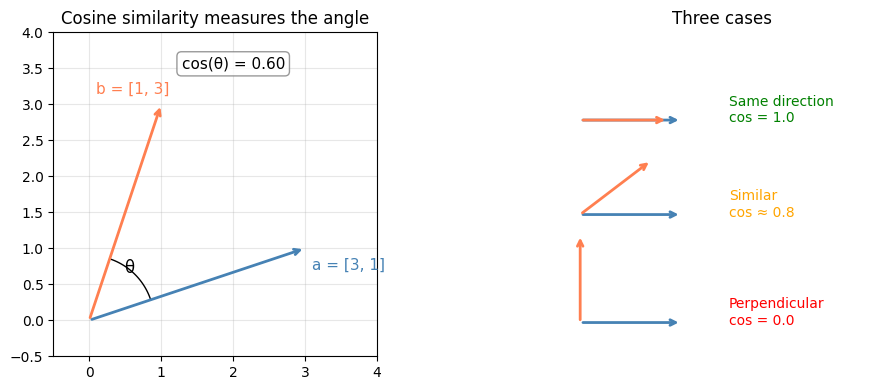

In [ ]:
#@title Optional: Visual Refresher on Cosine Similarity
# Skip this if the formula above is clear.

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Panel 1: two vectors and the angle between them
ax = axes[0]
a = np.array([3, 1])
b = np.array([1, 3])
ax.annotate("", xy=a, xytext=(0,0), arrowprops=dict(arrowstyle="->", color="steelblue", lw=2))
ax.annotate("", xy=b, xytext=(0,0), arrowprops=dict(arrowstyle="->", color="coral", lw=2))
ax.text(a[0]+0.1, a[1]-0.3, "a = [3, 1]", color="steelblue", fontsize=11)
ax.text(b[0]-0.9, b[1]+0.15, "b = [1, 3]", color="coral", fontsize=11)
angle_a = np.arctan2(a[1], a[0])
angle_b = np.arctan2(b[1], b[0])
arc = np.linspace(angle_a, angle_b, 30)
ax.plot(0.9*np.cos(arc), 0.9*np.sin(arc), 'k-', lw=1)
ax.text(0.55, 0.65, "\u03b8", fontsize=12, ha='center')
cos_val = np.dot(a,b) / (np.linalg.norm(a) * np.linalg.norm(b))
ax.text(2.0, 3.5, f"cos(\u03b8) = {cos_val:.2f}", fontsize=11, ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
ax.set_xlim(-0.5, 4); ax.set_ylim(-0.5, 4)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_title("Cosine similarity measures the angle")

# Panel 2: three cases
ax = axes[1]
cases = [
    (np.array([1.5, 0]),   np.array([1.3, 0]),    "Same direction\ncos = 1.0",  "green"),
    (np.array([1.5, 0]),   np.array([1.05, 0.8]),  "Similar\ncos \u2248 0.8",       "orange"),
    (np.array([1.5, 0]),   np.array([0, 1.3]),     "Perpendicular\ncos = 0.0",  "red"),
]
row_y = [3.0, 1.6, 0.0]
for (v1, v2, label, color), y in zip(cases, row_y):
    ax.annotate("", xy=(v1[0], v1[1]+y), xytext=(0, y),
                arrowprops=dict(arrowstyle="->", color="steelblue", lw=2))
    ax.annotate("", xy=(v2[0], v2[1]+y), xytext=(0, y),
                arrowprops=dict(arrowstyle="->", color="coral", lw=2))
    ax.text(2.2, y + 0.15, label, fontsize=10, va='center', color=color)
ax.set_xlim(-0.3, 4.5); ax.set_ylim(-0.5, 4.3)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title("Three cases")

plt.tight_layout()
plt.show()

### Exercise 2: Build Cosine Similarity from Scratch

Implement cosine similarity. First the dot product, then the L2 norm, then combine them. After implementing, you will see it applied to the BoW vectors from Exercise 1.

In [ ]:
def dot_product(a, b):
    """Compute dot product of two vectors."""
    # YOUR CODE HERE
    pass

def vector_norm(a):
    """Compute L2 norm (length) of a vector."""
    # YOUR CODE HERE
    pass

def cosine_similarity(a, b):
    """Compute cosine similarity using dot_product and vector_norm."""
    # YOUR CODE HERE
    pass

In [ ]:
#@title tests
# Test on simple examples first
x = np.array([1.0, 0.0])
y = np.array([0.0, 1.0])
z = np.array([1.0, 1.0])

print("Quick tests:")
print(f"  dot_product([1,0], [0,1]) = {dot_product(x, y)}  (should be 0.0)")
print(f"  dot_product([1,0], [1,1]) = {dot_product(x, z)}  (should be 1.0)")
print(f"  vector_norm([1,1])        = {vector_norm(z):.4f}  (should be 1.4142)")
print(f"  cosine_sim([1,0], [0,1])  = {cosine_similarity(x, y):.4f}  (should be 0.0)")
print(f"  cosine_sim([1,0], [1,1])  = {cosine_similarity(x, z):.4f}  (should be ~0.7071)")

# Now apply to our BoW vectors
print("\nBoW cosine similarities:")
for i in range(len(sentences)):
    for j in range(i+1, len(sentences)):
        sim = cosine_similarity(bow_vectors[i], bow_vectors[j])
        print(f"  {labels[i]:25s} <> {labels[j]:25s}  sim = {sim:.3f}")

**Where BoW hits its ceiling:** All BoW-family methods (raw counts, TF-IDF, topic models, dictionaries) represent text through **which words appear.** They work when different concepts use different vocabulary.

But look at sentences A and B above. Both are about economic policy, yet they share almost no words. BoW does not know that "fiscal" is related to "economic," or that "stimulate the economy" means the same thing as "economic growth." Every word is equally different from every other word: "cat" is as far from "dog" as from "democracy."

The problem is clear: **BoW captures what words appear, but not what they mean.** We need a representation where similar words are close together.


## 1.2 Word Embeddings: Words That Know Their Meaning

The breakthrough idea (Mikolov et al., 2013): instead of treating every word as a separate symbol, **learn a dense vector for each word from its context.** Words that appear in similar contexts get similar vectors.

This is the **distributional hypothesis**: "you shall know a word by the company it keeps" (Firth, 1957). A word that often appears near "government," "legislation," and "vote" will end up with a vector close to other political terms, even if they never appeared in the same sentence.


In [ ]:
import gensim.downloader as api

# Load GloVe embeddings (100-dimensional, trained on Wikipedia + Gigaword)
# This downloads ~128MB on first run
glove = api.load("glove-wiki-gigaword-100")
print(f"Loaded {len(glove):,} word vectors, each with {glove.vector_size} dimensions")

# What does a word vector look like?
print(f"\nVector for 'democracy':")
print(glove['democracy'])

Loading GloVe embeddings (this takes ~30-60 seconds the first time)...
Loaded 400,000 word vectors, each with 100 dimensions

Vector for 'democracy' (first 10 of 100 dimensions):
[-0.215     0.87737  -0.063965 -0.042852  0.86186   0.89338  -0.35324
 -0.99678   0.15289   0.066144 -0.52534   0.68397   0.34208  -0.1562
 -0.73768   0.20957   0.16697  -0.039477 -0.43481  -0.24743   0.43591
 -0.058181  0.65537  -0.28042   0.37273   0.36553   0.1083   -0.67762
  0.57978   0.38404   0.31276   1.0281    0.12181   0.47344   0.43453
 -0.5851    0.30595   0.43365  -1.0241   -0.72537  -1.7373   -0.65151
  0.80613  -0.15615  -0.27365  -1.0545    0.52086   0.15272  -0.60403
 -0.33367  -0.17697  -0.2755   -0.42711   1.3151    0.37881  -1.2953
  0.18912   0.41696   1.4792   -0.0141   -1.1892   -0.30676  -1.311
 -0.70105   0.67542   0.58331  -0.35846  -0.4816    0.31092  -0.065241
  1.3389    0.16039  -0.88174  -0.57881   0.21681  -0.17917  -0.10835
  0.25223  -0.9224   -0.28561   0.52446   0.40163   0.

In [ ]:
# Similar words are nearby in this space
for probe in ['democracy', 'parliament']:
    print(f"Most similar to '{probe}':")
    for word, score in glove.most_similar(probe, topn=8):
        print(f"  {word:20s} {score:.3f}")
    print()

# Your cosine_similarity from Exercise 1b works on real word vectors
sim = cosine_similarity(glove['fiscal'], glove['economic'])
print(f"cosine_similarity('fiscal', 'economic') = {sim:.3f}")

Words most similar to 'democracy':
  freedom              0.739
  unity                0.710
  independence         0.700
  political            0.677
  movement             0.669
  opposition           0.666
  peace                0.665
  freedoms             0.663

Words most similar to 'parliament':
  parliamentary        0.843
  assembly             0.781
  mps                  0.761
  commons              0.737
  duma                 0.723
  deputies             0.720
  cabinet              0.720
  elections            0.717

Cosine similarity('fiscal', 'economic') = 0.672


### Visualizing the Embedding Space

Each word lives in a 100-dimensional space. We cannot visualize 100 dimensions, but we can use **t-SNE** to project them down to 2D while preserving local neighborhood structure. Words that are close in the full space should stay close in the projection.


In [ ]:
#@title 📊 Visualize the embedding space (t-SNE → 2D)
from sklearn.manifold import TSNE
import plotly.graph_objects as go

# Pick ~100 common words from different domains
word_groups = {
    "politics":  ["government", "president", "congress", "senate", "election",
                  "democracy", "vote", "parliament", "legislation", "republican",
                  "democrat", "liberal", "conservative", "campaign", "policy"],
    "economy":   ["economy", "inflation", "growth", "trade", "market",
                  "fiscal", "budget", "tax", "employment", "recession",
                  "investment", "profit", "stock", "bank", "debt"],
    "science":   ["research", "experiment", "hypothesis", "theory", "data",
                  "evidence", "study", "analysis", "biology", "physics",
                  "chemistry", "discovery", "laboratory", "scientist", "method"],
    "military":  ["army", "military", "war", "soldier", "weapon",
                  "defense", "attack", "battle", "troops", "navy",
                  "general", "conflict", "peace", "security", "force"],
    "family":    ["family", "mother", "father", "child", "daughter",
                  "son", "husband", "wife", "brother", "sister",
                  "home", "parent", "baby", "love", "marriage"],
    "nature":    ["river", "mountain", "forest", "ocean", "tree",
                  "animal", "bird", "flower", "rain", "sky",
                  "earth", "sun", "wind", "snow", "water"],
    "food":      ["food", "bread", "meat", "rice", "fruit",
                  "vegetable", "cook", "eat", "dinner", "restaurant",
                  "sugar", "salt", "chicken", "cheese", "wine"],
}

# Collect vectors
all_group_words = []
all_vectors = []
all_group_labels = []
color_map = {
    "politics": "#e41a1c", "economy": "#377eb8", "science": "#4daf4a",
    "military": "#984ea3", "family": "#ff7f00", "nature": "#228B22", "food": "#a65628"
}

for group, words in word_groups.items():
    for w in words:
        if w in glove:
            all_group_words.append(w)
            all_vectors.append(glove[w])
            all_group_labels.append(group)

vectors_matrix = np.array(all_vectors)

# t-SNE projection to 2D
print(f"Projecting {len(all_group_words)} words from {glove.vector_size}D to 2D with t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
coords = tsne.fit_transform(vectors_matrix)

# Interactive plot with plotly (hover to see words, scroll to zoom)
fig = go.Figure()
for group, color in color_map.items():
    mask = [g == group for g in all_group_labels]
    xs = coords[mask, 0]
    ys = coords[mask, 1]
    words = [w for w, m in zip(all_group_words, mask) if m]
    fig.add_trace(go.Scatter(
        x=xs, y=ys, mode='markers+text',
        marker=dict(size=8, color=color, opacity=0.8),
        text=words, textposition='top center', textfont=dict(size=9),
        name=group, hoverinfo='text', hovertext=words,
    ))

fig.update_layout(
    title="Word embeddings projected to 2D with t-SNE",
    xaxis_title="t-SNE dimension 1", yaxis_title="t-SNE dimension 2",
    width=800, height=600,
    legend=dict(font=dict(size=11)),
    hovermode='closest',
)
fig.show()

Projecting 105 words from 100D to 2D with t-SNE...


-> Words from the same domain cluster together, even though
   the model was never told these categories exist.
   This structure emerged purely from word co-occurrence patterns.
   (Hover over points to see words. Scroll to zoom in.)


### Exercise 3: Word Analogies

Word embeddings encode **relationships as directions.** The famous example: "king - man + woman ≈ queen." This works because the direction from "man" to "king" captures something like "royalty," and adding that direction to "woman" lands near "queen."

**Tasks:**
1. Use `glove.most_similar(positive=[...], negative=[...])` to test these analogies:
   - king - man + woman = ?
   - paris - france + germany = ?
2. Invent 2 of your own (at least one that works, one that fails).
3. Pick a political concept (e.g., "terrorism", "immigration", "freedom") and look at its nearest neighbors. What does the embedding space "think" this concept means?

In [ ]:
# TASK 1: Word analogies
# Syntax: glove.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)

# YOUR CODE HERE: test at least 4 analogies


# TASK 2: Explore a political concept's neighborhood
# YOUR CODE HERE



## 1.3 Semantic Projection: Embeddings Capture More Than You See

A 100-dimensional vector seems abstract, but it encodes rich, interpretable structure. The technique of **semantic projection** reveals this: define a meaningful direction using pairs of anchor words, then project other words onto that axis to see where they fall.

For example, a "gender" direction can be defined using anchors like (man, woman), (he, she), (him, her). Projecting occupations onto this axis reveals how strongly the training corpus associates each occupation with gender. Caliskan et al. (2017) showed that embeddings replicate every implicit bias measured in humans. Kozlowski et al. (2019) used this technique to map cultural dimensions like class and status.

The key insight: embeddings encode **many more meaningful dimensions** than the 100 numbers would suggest. Gender, valence, formality, political leaning, concreteness: each is a direction in the space, and they can be extracted and measured.


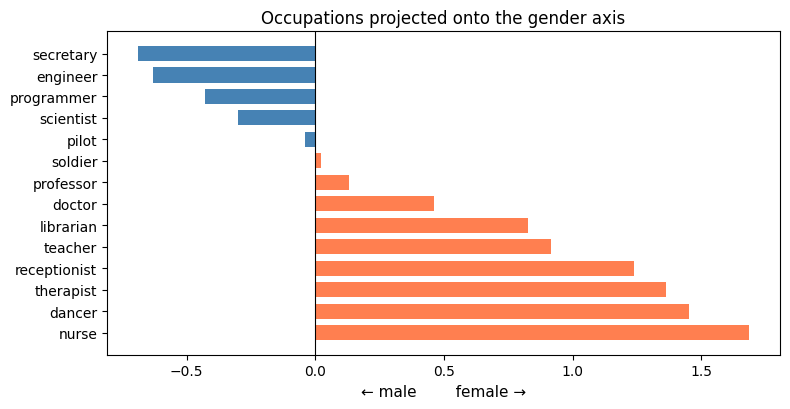

In [ ]:
#@title ⚙️ Helper functions: semantic_axis, project_words, plot_projection
def semantic_axis(glove, positive_anchors, negative_anchors):
    """Create a semantic direction from anchor word pairs. Returns a unit vector."""
    pos = np.mean([glove[w] for w in positive_anchors], axis=0)
    neg = np.mean([glove[w] for w in negative_anchors], axis=0)
    direction = pos - neg
    return direction / np.linalg.norm(direction)

def project_words(glove, words, axis):
    """Project words onto a semantic axis. Returns sorted (word, score) pairs."""
    results = []
    for w in words:
        if w in glove:
            score = float(np.dot(glove[w], axis))
            results.append((w, score))
    return sorted(results, key=lambda x: x[1])

def plot_projection(projections, left_label, right_label, title):
    """Visualize words projected onto a semantic axis as a diverging bar chart."""
    words, scores = zip(*projections)
    colors = ['steelblue' if s < 0 else 'coral' for s in scores]

    fig, ax = plt.subplots(figsize=(8, max(3, len(words) * 0.3)))
    ax.barh(range(len(words)), scores, color=colors, height=0.7)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=10)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel(f"← {left_label}        {right_label} →", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

# Demo: gender axis
gender_axis = semantic_axis(glove, ['woman', 'she', 'her'], ['man', 'he', 'him'])

occupations = ['nurse', 'doctor', 'teacher', 'engineer', 'secretary',
               'professor', 'soldier', 'dancer', 'programmer', 'receptionist',
               'scientist', 'librarian', 'pilot', 'therapist']

plot_projection(
    project_words(glove, occupations, gender_axis),
    left_label="male", right_label="female",
    title="Occupations projected onto the gender axis"
)

**Key takeaway from Section 1:** Word embeddings capture the *meaning* of individual words as geometry: similar words are close, relationships are directions, and many interpretable dimensions (gender, valence, ideology) can be extracted from the space.

But we started this section wanting to capture what a *text* is about, not just what individual words mean. How do we go from word vectors back to text-level understanding? We could average word vectors for a sentence, but that is crude: "dog bites man" and "man bites dog" would get the same representation. We could train dedicated document embeddings (Doc2Vec), but they are limited in what they capture.

The solution turns out to be something more powerful: **language models.** Instead of representing text as a static vector, a language model *reads* the full sequence and builds context-dependent representations. The core idea is disarmingly simple: **predict the next token.** A model that does this well must implicitly learn grammar, facts, reasoning, and much more. This single objective has produced not just powerful text comprehension systems, but state-of-the-art AI that writes code, solves math problems, and reasons about the world.


---
# **Section 2: From Static Vectors to Language Understanding**
*What a real language model can do, and how it works*

---

GloVe gives every word a fixed vector: "bank" has the same representation whether you are talking about a river or a financial institution. A modern language model does something much more powerful: it reads the whole sequence and builds **context-dependent representations.**

Let's see this in action. We will load **Qwen3-0.6B**, a small but capable model released in 2025 with 600 million parameters.


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

qwen_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-0.6B")
qwen_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen3-0.6B",
    torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    output_attentions=True,
).to(device)
qwen_model.eval()

n_params = sum(p.numel() for p in qwen_model.parameters())
print(f"Qwen3-0.6B loaded: {n_params/1e6:.0f}M parameters, "
      f"{qwen_model.config.num_hidden_layers} layers, "
      f"{qwen_tokenizer.vocab_size:,} token vocabulary. Device: {device}.")

Loading Qwen3-0.6B (this may take 1-2 minutes the first time)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Loaded Qwen3-0.6B: 752M parameters
  Architecture: 28 layers, 16 attention heads
  Vocabulary: 151,643 tokens


## 2.1 Next-Token Prediction: The Core Idea

Every language model, from GPT-2 (2019, 124M parameters) to Claude and GPT-4 (hundreds of billions), does the same fundamental thing: **given a sequence of text, predict what comes next.**

The model outputs a probability distribution over its entire vocabulary for the next token. Let's look inside:


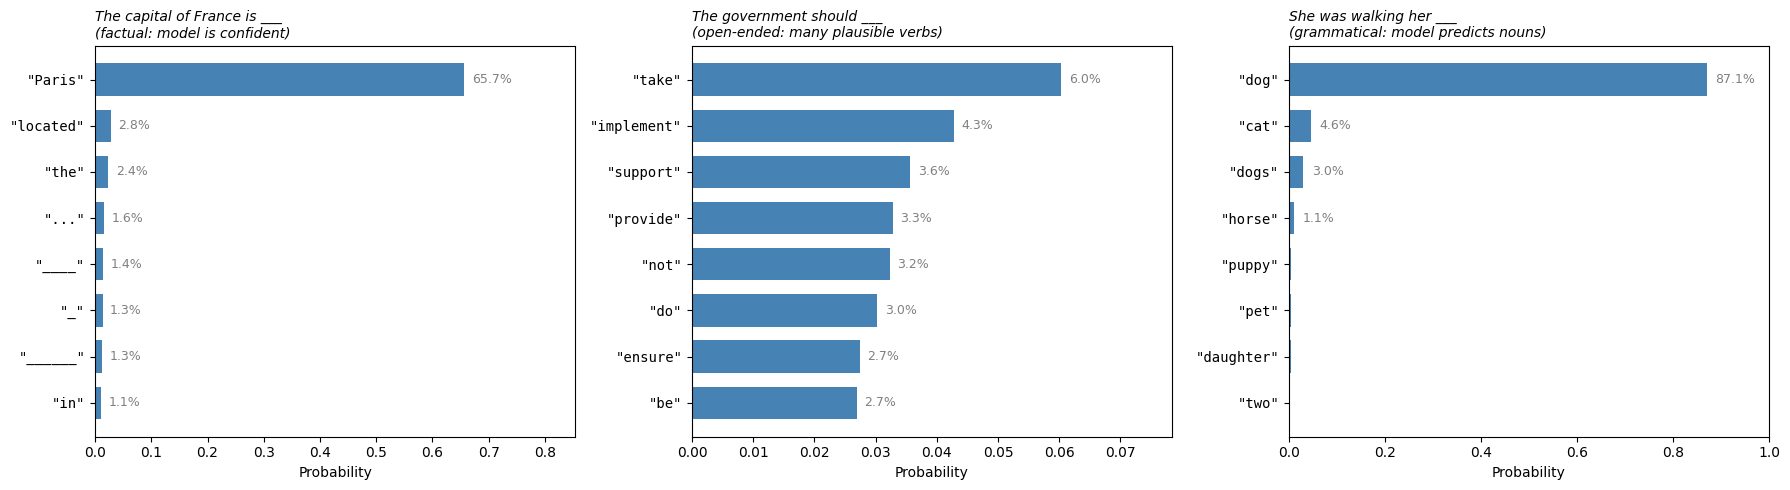

In [ ]:
#@title ⚙️ Helper: show_next_token_probs()
def show_next_token_probs(model, tokenizer, text, top_k=10, ax=None):
    """Show the model's top predicted next tokens as a bar chart."""
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits[0, -1, :]
    probs = torch.softmax(logits, dim=-1)
    top_probs, top_ids = probs.topk(top_k)

    tokens = [tokenizer.decode([idx.item()]).strip() or "_" for idx in top_ids]
    values = [p.item() for p in top_probs]

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, max(2.5, top_k * 0.3)))

    bars = ax.barh(range(top_k), values, color='steelblue', height=0.7)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels([f'"{t}"' for t in tokens], fontsize=10, family='monospace')
    ax.set_xlabel("Probability")
    ax.set_title(f'{text}  ___', fontsize=11, loc='left', style='italic')
    ax.invert_yaxis()
    ax.set_xlim(0, min(1.0, max(values) * 1.3))

    # Annotate top bar with percentage
    for i, v in enumerate(values):
        if v > 0.01:
            ax.text(v + max(values)*0.02, i, f"{v:.1%}", va='center', fontsize=9, color='gray')

    return probs


# Compare three prompts side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

show_next_token_probs(qwen_model, qwen_tokenizer,
    "The capital of France is", top_k=8, ax=axes[0])
axes[0].set_title("""The capital of France is ___
(factual: model is confident)""", fontsize=10, loc='left')

show_next_token_probs(qwen_model, qwen_tokenizer,
    "The government should", top_k=8, ax=axes[1])
axes[1].set_title("""The government should ___
(open-ended: many plausible verbs)""", fontsize=10, loc='left')

show_next_token_probs(qwen_model, qwen_tokenizer,
    "She was walking her", top_k=8, ax=axes[2])
axes[2].set_title("""She was walking her ___
(grammatical: model predicts nouns)""", fontsize=10, loc='left')

plt.tight_layout()
plt.show()

Notice three things:
1. **Factual knowledge:** The model is highly confident that "Paris" follows "The capital of France is"
2. **Open-ended understanding:** For "The government should", the model distributes probability across many plausible policy verbs
3. **Grammar:** After "She was walking her", the model predicts nouns (dog, cat...): it has learned syntax

All from a single objective: predict the next token.


## 2.2 Beyond Static Embeddings: Contextual Understanding

Here is something GloVe cannot do. Watch how the model's predictions change based on context, showing that it builds *different* internal representations of the same word:


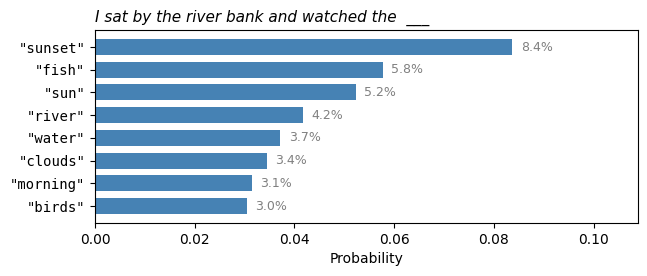

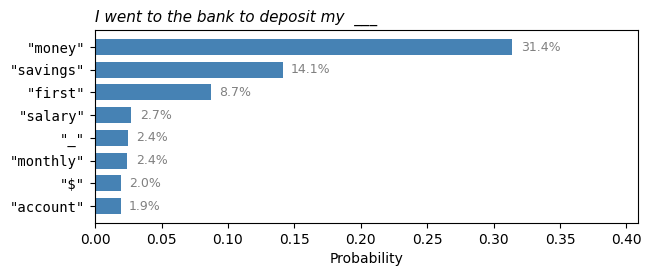

In [ ]:
# The word "bank" in different contexts
show_next_token_probs(qwen_model, qwen_tokenizer,
    "I sat by the river bank and watched the", top_k=8)


show_next_token_probs(qwen_model, qwen_tokenizer,
    "I went to the bank to deposit my", top_k=8);

Long-range understanding:



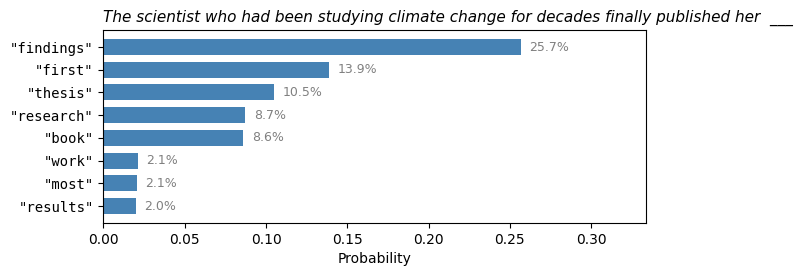

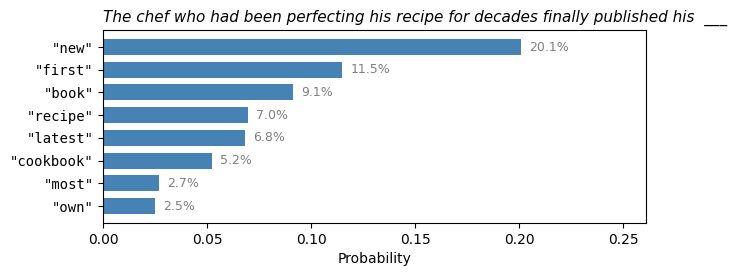

In [ ]:
# The model tracks long-range dependencies
print("Long-range understanding:\n")

show_next_token_probs(qwen_model, qwen_tokenizer,
    "The scientist who had been studying climate change for decades finally published her", top_k=8)

show_next_token_probs(qwen_model, qwen_tokenizer,
    "The chef who had been perfecting his recipe for decades finally published his", top_k=8);

## 2.3 What Makes This Possible?

How does a language model go from static word vectors to this rich contextual understanding? Three key ingredients:

1. **Tokenization**: how text gets converted into the numbers the model processes
2. **Attention**: the mechanism that lets each word "look at" every other word to build context-dependent representations
3. **Scale**: parameters, data, and compute that turn these mechanisms into genuine understanding

Let's unpack each of these.


---
# **Section 3: How Models See Text**
*Tokenization: from strings to numbers*

---

We just saw Qwen3 predict next tokens. But what is a "token"? The model does not see words. It sees **tokens**, which are integer IDs mapped to subword units.

Why not just split on spaces? Three reasons:
1. **Vocabulary size**: English has millions of word forms. A model cannot have a separate vector for every one.
2. **Unknown words**: what happens when the model encounters a word it has never seen?
3. **Morphology**: "running", "runs", "ran" are related. A good tokenizer should capture this.


### The Out-of-Vocabulary Problem

The simplest tokenizer splits text on spaces and maps each word to an integer. But what happens when it encounters a word not in its vocabulary?

In [ ]:
#@title 📊 Demo: Word-level tokenizer hits a wall
# A toy word-level tokenizer trained on one sentence
training_text = "the senator proposed immigration reform"
vocab = {w: i+1 for i, w in enumerate(sorted(set(training_text.lower().split())))}
vocab["<UNK>"] = 0

def word_tokenize(text, vocab):
    return [vocab.get(w, 0) for w in text.lower().split()]

# Works fine on familiar text
print("Known text:", word_tokenize("the senator proposed reform", vocab))

# Fails on new vocabulary: everything becomes <UNK>
print("New text:  ", word_tokenize("the congressman suggested policy changes", vocab))
print("           ↑ 3 out of 5 words lost: all mapped to <UNK> (0)")

**The out-of-vocabulary (OOV) problem:** Our word-level tokenizer loses *all information* about unseen words. In social science research, where you analyze novel texts with domain-specific vocabulary, this is catastrophic.

## 3.2 Byte-Pair Encoding: The Real Solution

Modern language models use **subword tokenization.** The most common algorithm is **Byte-Pair Encoding (BPE)** (Sennrich et al., 2016):

1. Start with individual characters as your vocabulary
2. Find the most frequent pair of adjacent tokens in the training data
3. Merge that pair into a new token
4. Repeat until you reach your desired vocabulary size

The result:
- **Common words** ("the", "and") → single token
- **Rare words** ("democratization") → split into subwords ("demo" + "crat" + "ization")
- **Nothing is ever unknown**: in the worst case, the model falls back to individual characters

Let's see what a real tokenizer looks like. We'll use the one inside Qwen3 (the model we loaded in Section 2):


In [ ]:
# Let's use the Qwen3 tokenizer we already loaded
print(f"Qwen3 vocabulary size: {qwen_tokenizer.vocab_size:,} tokens\n")

text = "The senator proposed immigration reform"
qwen_tokens = qwen_tokenizer.encode(text)
print(f"Text: '{text}'")
print(f"Token IDs: {qwen_tokens}")
print(f"Subwords:  {[qwen_tokenizer.decode([t]) for t in qwen_tokens]}")

# Now try a word it has probably never seen as a single unit
text2 = "The congressman discussed gerrymandering"
tokens2 = qwen_tokenizer.encode(text2)
print(f"\nText: '{text2}'")
print(f"Subwords:  {[qwen_tokenizer.decode([t]) for t in tokens2]}")
print("↑ BPE splits rare words into known subwords. Nothing is ever <UNK>")

Qwen3 vocabulary size: 151,643 tokens

Our word tokenizer:  [18, 0, 0, 0, 0]
  Decoded: 'the <UNK> <UNK> <UNK> <UNK>'

Qwen3 BPE tokenizer: [785, 31697, 10981, 15093, 14836]
  Decoded: 'The senator proposed immigration reform'
  Token-by-token: ['The', ' senator', ' proposed', ' immigration', ' reform']

→ No information lost! Every word is represented, even ones the
  tokenizer has never seen as a complete word.


### Exercise 4: Tokenizer Detective

Tokenization has **real consequences** for model behavior. Investigate how BPE handles different inputs.

**Tasks:**
1. **The "strawberry" test:** How many tokens does "strawberry" need? Try "Strawberry" and "STRAWBERRY" too. Why might a model struggle to count letters if the word is split into subwords?
2. **Multilingual inequality:** Compare "The United Nations discussed climate change" in English and 1-2 other languages. Which language is cheapest?
3. **Social science terms:** Try names of political figures, technical jargon, non-English place names. What gets split?
4. **Numbers:** Try "1234", "12.34", and "one thousand two hundred thirty four". How does the tokenizer handle each?

In [ ]:
#@title ⚙️ Helper: show_tokens()
def show_tokens(text, tokenizer=qwen_tokenizer):
    """Show how a tokenizer splits text."""
    tokens = tokenizer.encode(text)
    pieces = [tokenizer.decode([t]) for t in tokens]
    print(f"'{text}'")
    print(f"  {len(tokens)} tokens: {pieces}\n")

In [ ]:
# TASK 1: The "strawberry" test
# YOUR CODE HERE


# TASK 2: Multilingual comparison
# YOUR CODE HERE
# Try: "The United Nations discussed climate change" in English + other languages


# TASK 3: Social science terms and names
# YOUR CODE HERE


# TASK 4: Numbers
# YOUR CODE HERE

**Key takeaway from Section 3:** Tokenization is the bridge between human text and model computation. BPE solves the unknown-word problem elegantly but introduces its own artifacts: subword splits, multilingual inequality, and number fragmentation. When working with LLMs, **the tokenizer is part of your measurement instrument.**


## The Transformer Architecture

Before diving into attention, let's see where it fits. A transformer is a stack of identical **blocks**, each with two main components:

```
Input text
  → Tokenizer → Token IDs
  → Embedding layer → vectors (one per token)
  → [Transformer Block] × N layers
  → Output logits (probability over vocabulary)

Each Transformer Block:
  ┌─────────────────────────────────┐
  │  Layer Norm                      │
  │  → Multi-Head Attention          │  ← tokens talk to each other
  │  → + residual connection         │
  │  Layer Norm                      │
  │  → MLP (feed-forward network)    │  ← each token processed independently
  │  → + residual connection         │
  └─────────────────────────────────┘
```

**Attention** is where tokens communicate: each token looks at the other tokens to gather context. This is the part we will focus on.

**The MLP** (a simple two-layer neural network) processes each token *independently* after attention. It acts as a learned lookup table, storing factual knowledge ("Paris is the capital of France") and transforming the representations that attention assembled.

**Residual connections** (the "+" steps) add the input of each sub-layer back to its output. This lets information flow directly through many layers without degradation, and is the reason transformers can be stacked 28, 96, or even 128 layers deep.

Why does this architecture dominate modern AI? Two reasons:
1. **Parallelism.** Unlike earlier sequence models (RNNs, LSTMs) that process tokens one at a time, attention processes all tokens *simultaneously*. This makes transformers far more efficient to train on modern hardware.
2. **Compositionality.** Each layer builds richer representations on top of the previous one. Early layers capture syntax and local patterns; later layers capture meaning, coreference, and reasoning.

Qwen3-0.6B, the model we loaded earlier, has 28 of these blocks stacked on top of each other. That means each token goes through 28 rounds of "look at context" (attention) followed by "process independently" (MLP) before the model makes its prediction.

---
# **Section 4: Attention: How Models Decide What Matters**
*The mechanism at the heart of every modern language model*

---

We now know that attention is where tokens communicate inside a transformer block. But what does that actually look like? Before we formalize the math, let's build intuition by doing it ourselves.

### Exercise 5: Be the Attention Mechanism

When you read a sentence and predict what comes next, you do not weigh every word equally. Some words matter more than others for the prediction.

**Task:** For each sentence below, a word is missing (marked `___`). Assign an **importance weight** to each word: how much does it help predict the blank? Weights must be between 0 and 1 and sum to 1.

Think carefully: which words carry the most information for the prediction? Which are filler?

In [ ]:
# Assign importance weights to each word for predicting the blank.
# Weights must be between 0 and 1, and sum to 1 for each sentence.

# Sentence 1: "The prime minister of the United Kingdom met with the ___"
words_1 = ["The", "prime", "minister", "of", "the", "United", "Kingdom", "met", "with", "the"]
weights_1 = [0.0] * 10  # YOUR WEIGHTS HERE: e.g. [0.0, 0.3, 0.1, ...]

# Sentence 2: "The doctor told the patient that she should ___"
words_2 = ["The", "doctor", "told", "the", "patient", "that", "she", "should"]
weights_2 = [0.0] * 8  # YOUR WEIGHTS HERE

# Sentence 3: "After years of conflict, the two nations finally signed a ___"
words_3 = ["After", "years", "of", "conflict", "the", "two", "nations", "finally", "signed", "a"]
weights_3 = [0.0] * 10  # YOUR WEIGHTS HERE

# --- Visualize your weights ---
fig, axes = plt.subplots(3, 1, figsize=(12, 7))
for ax, words, weights, sent_num in zip(axes, [words_1, words_2, words_3],
                                         [weights_1, weights_2, weights_3],
                                         [1, 2, 3]):
    colors = plt.cm.Blues(np.array(weights) / max(max(weights), 0.01))
    bars = ax.bar(range(len(words)), weights, color=colors, edgecolor='steelblue')
    ax.set_xticks(range(len(words)))
    ax.set_xticklabels(words, fontsize=10)
    ax.set_ylabel("Weight")
    ax.set_title(f"Sentence {sent_num}: {'  '.join(words)} ___")
    ax.set_ylim(0, max(max(weights), 0.01) * 1.3)

plt.tight_layout()
plt.show()

# Check: do weights sum to ~1?
for i, (w, name) in enumerate([(weights_1, "S1"), (weights_2, "S2"), (weights_3, "S3")]):
    total = sum(w)
    status = "✓" if abs(total - 1.0) < 0.05 else f"⚠ (sums to {total:.2f}, should be ~1.0)"
    print(f"  {name} weight sum: {total:.2f} {status}")

### Context Changes Everything

Notice something deeper: the weights you assign depend on **what you are trying to predict.** The same word can demand completely different attention patterns depending on context.

Consider the word "bank" in these two sentences:


In [ ]:
#@title 📊 "bank" in two contexts: where does attention go?
# Same word, different context: where does your attention go?
s1_words = ["I", "sat", "by", "the", "river", "bank"]
s2_words = ["I", "went", "to", "the", "bank", "to", "deposit", "my", "money"]

fig, axes = plt.subplots(1, 2, figsize=(12, 2.5))

for ax, words, highlight, title in [
    (axes[0], s1_words, {"river": 0.5, "sat": 0.2, "by": 0.15, "bank": 0.15},
     '"bank" = riverbank'),
    (axes[1], s2_words, {"deposit": 0.4, "money": 0.3, "bank": 0.2, "went": 0.1},
     '"bank" = financial institution'),
]:
    weights = [highlight.get(w, 0.0) for w in words]
    colors = plt.cm.Blues(np.array(weights) / max(max(weights), 0.01))
    ax.bar(range(len(words)), weights, color=colors, edgecolor='steelblue')
    ax.set_xticks(range(len(words)))
    ax.set_xticklabels(words, fontsize=10)
    ax.set_ylabel("Weight")
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0, 0.65)

plt.suptitle("Same word, different context: different attention patterns", fontsize=11)
plt.tight_layout()
plt.show()

### Why One Set of Weights Is Not Enough

Now consider a more complex sentence:

*"The doctor from London told the patient that she should ___"*

To predict the blank, you need to answer several questions **simultaneously**:
- **Who** should do something? → look at "doctor" and "patient"
- **What kind** of action? → look at "doctor," "told," medical context
- **Who** does "she" refer to? → look at "doctor" or "patient" (grammar/context)

Try to capture all three with a single set of weights. You will find yourself compromising: putting weight on "doctor" for both the who-question and the what-kind question, with no way to separate those roles.

This is why transformers use **multi-head attention**: multiple sets of weights running in parallel, each one asking a different question about the sequence. One head might track syntax (subject-verb), another might track coreference ("she" → "patient"), another might focus on local context (the word right before the blank).


## 4.2 The Attention Mechanism: Formalizing Your Intuition

What you did by hand, the model does with linear algebra. Here is the recipe:

1. Each token vector is transformed into three vectors: **Query (Q)**, **Key (K)**, **Value (V)**
2. The **Query** asks: "what am I looking for?" (your question about the blank)
3. Each **Key** says: "here is what I contain" (what each word offers)
4. **Attention scores** = how well each Query matches each Key (dot product)
5. Scores are **scaled** (by $\sqrt{d_k}$) and passed through **softmax**, giving weights that sum to 1
6. Output = weighted sum of **Values** (the information you extract)

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

One critical detail: **causal masking.** Since the model predicts the *next* token, each token can only attend to itself and earlier tokens. No peeking at the future.


### Exercise 6: Compute Attention with Math

Now let's formalize what you did by hand. We have 4 tokens with pre-defined Q, K, V matrices (in a real model, these are learned). Work through each step of the attention computation.

In [ ]:
#@title ⚙️ Setup: Q, K, V matrices for 4 tokens
# Setup: 4 tokens, each with 3-dimensional Q, K, V vectors
tokens = ["The", "cat", "sat", "down"]
d_k = 3  # dimension of key vectors

Q = torch.tensor([
    [1.0, 0.1, 0.0],   # "The" query
    [0.2, 1.0, 0.3],   # "cat" query
    [0.0, 0.3, 1.0],   # "sat" query
    [0.1, 0.8, 0.2],   # "down" query
])
K = torch.tensor([
    [0.8, 0.0, 0.1],   # "The" key
    [0.1, 0.9, 0.2],   # "cat" key
    [0.0, 0.2, 0.9],   # "sat" key
    [0.2, 0.7, 0.3],   # "down" key
])
V = torch.tensor([
    [1.0, 0.0, 0.0],   # "The" value
    [0.0, 1.0, 0.0],   # "cat" value
    [0.0, 0.0, 1.0],   # "sat" value
    [0.5, 0.5, 0.0],   # "down" value
])

In [ ]:
# STEP 1: Compute raw attention scores (Q · Kᵀ)
# How well does each token's query match each token's key?
# YOUR CODE HERE
# scores = ...
# print("Step 1: Raw scores (Q·Kᵀ):"); print(scores.round(decimals=3))


# STEP 2: Scale by √d_k (prevents softmax from becoming too sharp)
# YOUR CODE HERE
# scaled = ...
# print(f"\nStep 2: Scaled (÷ √{d_k}):"); print(scaled.round(decimals=3))


# STEP 3: Causal mask (each token can only see itself and earlier tokens)
# Set upper-triangle to -inf so softmax gives them ~0 weight.
# Hint: torch.triu(torch.ones(4,4), diagonal=1).bool()
# Hint: tensor.masked_fill(mask, float('-inf'))
# YOUR CODE HERE
# mask = ...
# masked = ...
# print("\nStep 3: Masked:"); print(masked.round(decimals=3))


# STEP 4: Softmax (each row sums to 1: these are your attention weights)
# YOUR CODE HERE
# weights = ...
# print("\nStep 4: Attention weights:"); print(weights.round(decimals=3))


# STEP 5: Weighted sum of values (extract information)
# YOUR CODE HERE
# output = ...
# print("\nStep 5: Output:"); print(output.round(decimals=3))


# INTERPRET: Which token does "down" (row 3) attend to most? Why?


**Key takeaway from Section 4:** Attention lets each token "look at" every other token to decide what is relevant. You did this by hand in Exercise 5: you assigned importance weights based on what helps predict the next word. The model does the same thing, but with learned Q, K, V transformations and multiple heads running in parallel. Early layers capture local patterns (grammar, adjacent words); later layers capture long-range relationships (coreference, discourse structure).

### Practical Implications: Context Windows and Memory

Understanding attention is not just theory. It explains the constraints you hit when working with commercial AI models.

**Context window.** Attention computes a score between *every pair* of tokens. For a sequence of length $L$, that is $L^2$ scores per head per layer. Double the sequence, quadruple the computation. This is why every model has a maximum **context window** (e.g. 8K, 128K, 200K tokens), and why processing very long documents costs more. Critically, the context window is a **shared budget for input and output combined.** If a model has a 128K context window and your input is 120K tokens, you have at most 8K tokens left for the model's response.

**The KV cache.** When a model generates text token by token, it does not recompute attention from scratch each time. Instead, it stores the Key and Value vectors from all previous tokens (the "KV cache") and only computes Q for the new token. This is fast but memory-hungry: the cache grows with every token generated, across every layer and every head. For a 28-layer model with 16 heads, generating a 4,000-token response means storing 28 × 16 × 4,000 vectors in GPU memory.

**Why API pricing is per-token.** Now you can see the full picture:
- More tokens in = more attention computation ($L^2$)
- More tokens out = larger KV cache = more memory
- This is why you pay per input token *and* per output token, with output often costing more

**The link to tokenization.** Remember from Section 3 that different languages produce different numbers of tokens for the same content. A 1,000-word document in English might be ~1,300 tokens, while the same content in Chinese might be ~800 tokens, or in Thai ~2,500. This means the same analysis costs different amounts depending on language, not because the model is biased but because of how BPE tokenization works.

**Back-of-envelope for your research.** Suppose you want to classify 10,000 newspaper articles averaging 800 words each. That is roughly 10,000 × 1,000 tokens = 10M input tokens. At ~3 USD per million input tokens (a typical rate for a mid-range model), that is about ~30 USD for the full corpus, not counting the output tokens. These numbers matter when you are planning a research budget.

### Seeing Attention in Our Model

We have been building intuitions by hand and with toy matrices. Let's see what the attention patterns look like inside the actual Qwen3 model we loaded. The model has 28 layers × 16 heads = 448 separate attention patterns. Use the sliders to explore.

In [ ]:
#@title ⚙️ Attention visualization helpers
from ipywidgets import interact, IntSlider, Checkbox

def get_attention_maps(model, tokenizer, text):
    """Extract attention weights from all layers.
    Returns: attn [layers, heads, seq, seq], tokens [list of str]
    """
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    attn = torch.stack(outputs.attentions).squeeze(1).cpu()  # [layers, heads, seq, seq]
    tokens = [tokenizer.decode([t]) for t in inputs["input_ids"][0]]
    return attn, tokens

def plot_attention_head(attn, tokens, layer, head, ax=None):
    """Plot a single attention head as a heatmap."""
    data = attn[layer, head].numpy()
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(data, vmin=0, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90, fontsize=8)
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_xlabel("Key (attends to)")
    ax.set_ylabel("Query (current token)")
    ax.set_title(f"Layer {layer}, Head {head}")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return ax

In [ ]:
# Visualize attention patterns in Qwen3
text = "The prime minister of the United Kingdom met with the president"
attn, tokens = get_attention_maps(qwen_model, qwen_tokenizer, text)
print(f"Shape: {attn.shape}  =  (layers, heads, tokens, tokens)")
print(f"Tokens: {tokens}\n")

@interact(
    layer=IntSlider(value=0, min=0, max=attn.shape[0]-1, description="Layer"),
    head=IntSlider(value=0, min=0, max=attn.shape[1]-1, description="Head"),
)
def show_head(layer, head):
    fig, ax = plt.subplots(figsize=(6, 5))
    plot_attention_head(attn, tokens, layer, head, ax=ax)
    plt.tight_layout()
    plt.show()

# Things to look for:
# - Layer 0: do any heads attend mostly to the previous token?
# - Later layers: can you find a head that links "minister" to "prime"?
# - Compare early layers (local patterns) vs. late layers (long-range)

---
# **Section 5: Generation**
*Building a text generator from scratch*

---

We have all the ingredients: embeddings, tokenization, and attention. Now let's see how the model actually **generates text.** The core loop is simple: predict the next token, append it, repeat.

We will keep using Qwen3 for this section. Before building a generator, let's look at what happens in a single forward pass.

In [ ]:
#@title 📊 Demo: One forward pass
# One forward pass: prompt → logits → probabilities → predicted token
prompt = "The capital of France is"
inputs = qwen_tokenizer(prompt, return_tensors="pt").to(device)
input_ids = inputs["input_ids"]

# Forward pass
with torch.no_grad():
    outputs = qwen_model(**inputs)

logits = outputs.logits          # shape: (1, seq_len, vocab_size)
next_logits = logits[0, -1, :]   # logits for the NEXT token: shape (vocab_size,)

print(f"Input: '{prompt}' ({input_ids.shape[1]} tokens)")
print(f"Output: {next_logits.shape[0]:,} scores (one per vocab token)\n")

# Convert logits to probabilities
probs = torch.softmax(next_logits, dim=-1)
top_probs, top_ids = probs.topk(10)

print("Top 10 predicted next tokens:")
for prob, idx in zip(top_probs, top_ids):
    token = qwen_tokenizer.decode([idx.item()]).strip() or "_"
    print(f"  {token:15s} {prob.item():.3f}")

That is the complete picture of one step. To generate a full sequence, we repeat this in a loop: predict the next token, append it to the input, and predict again.


### Exercise 7: Build a Text Generator

Write a function that generates text one token at a time using **greedy decoding**: always pick the highest-probability token.

**The algorithm:**
```
1. Tokenize the prompt → input_ids
2. Repeat max_new_tokens times:
   a. Forward pass: logits = model(input_ids).logits
   b. Get logits for the last position: next_logits = logits[0, -1, :]
   c. Pick the token with the highest logit: next_id = next_logits.argmax()
   d. Append next_id to input_ids
3. Decode and return the full sequence
```

In [ ]:
def generate_greedy(model, tokenizer, prompt, max_new_tokens=30):
    """Generate text using greedy decoding (always pick the most likely token)."""
    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"].to(device)

    for _ in range(max_new_tokens):
        # YOUR CODE HERE
        # 1. Forward pass (inside torch.no_grad())
        # 2. Get next-token logits (last position)
        # 3. Pick the argmax
        # 4. Append to input_ids
        pass

    return tokenizer.decode(input_ids[0], skip_special_tokens=True)


# Test it
print(generate_greedy(qwen_model, qwen_tokenizer, "The capital of France is"))
print()
print(generate_greedy(qwen_model, qwen_tokenizer, "The future of democracy depends on"))

### Exploring Generation

Greedy decoding always picks the top token, which leads to repetitive, "safe" text. Real language models use **sampling with controls**: temperature (how random), top-k (consider only the k most likely tokens), and top-p (consider tokens until cumulative probability exceeds p). We will explore these in the Extensions, but for now, here is a `generate()` function with all the controls built in.

In [ ]:
#@title ⚙️ Full generate() with temperature, top-k, top-p
def generate(model, tokenizer, prompt, max_new_tokens=40,
             temperature=1.0, top_k=0, top_p=1.0):
    """Generate text with temperature, top-k, and top-p control."""
    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"].to(device)

    for _ in range(max_new_tokens):
        with torch.no_grad():
            outputs = model(input_ids)
        next_logits = outputs.logits[0, -1, :].clone()

        # Temperature scaling
        next_logits = next_logits / temperature

        # Top-k filtering
        if top_k > 0:
            top_values, _ = torch.topk(next_logits, top_k)
            threshold = top_values[-1]
            next_logits[next_logits < threshold] = -float('inf')

        # Top-p (nucleus) filtering
        if top_p < 1.0:
            sorted_logits, sorted_indices = torch.sort(next_logits, descending=True)
            sorted_probs = torch.softmax(sorted_logits, dim=-1)
            cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

            # Remove tokens with cumulative probability above threshold
            # Shift right so the first token above p is kept
            sorted_mask = cumulative_probs - sorted_probs > top_p
            sorted_logits[sorted_mask] = -float('inf')

            # Unsort: put filtered logits back in original order
            next_logits = torch.zeros_like(next_logits).scatter_(0, sorted_indices, sorted_logits)

        # Sample
        probs = torch.softmax(next_logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        input_ids = torch.cat([input_ids, next_id.unsqueeze(0)], dim=1)

    return tokenizer.decode(input_ids[0], skip_special_tokens=True)

print("generate() loaded. Try it with different prompts and settings.")

Try different prompts and parameter settings. Notice how a **base model does not follow instructions.** It completes text, it does not answer questions. This is the gap that Day 2 addresses.

In [ ]:
# Explore: how do decoding parameters change the "opinions" of the model?
prompt = "The main cause of political polarization is"

print("--- Greedy (T=0.1) ---")
print(generate(qwen_model, qwen_tokenizer, prompt, temperature=0.1))
print()
print("--- Creative (T=1.0, top_p=0.9) ---")
print(generate(qwen_model, qwen_tokenizer, prompt, temperature=1.0, top_p=0.9))
print()

# Try your own prompts!
# "Immigration policy should"
# "The role of government in healthcare"

In [ ]:
# A base model does not follow instructions. It COMPLETES text.
prompt = "Please summarize the following article about climate change:"
print(f"Prompt: {prompt}\n")
print(generate(qwen_model, qwen_tokenizer, prompt, temperature=0.7, top_p=0.9))

---
## What We Covered Today

You now have a hands-on understanding of the **key building blocks** behind modern language models:

| Section | Key Idea | Why It Matters |
|---------|----------|----------------|
| **Representing Meaning** | Words as vectors with meaningful geometry | Embeddings encode cultural knowledge (and biases) |
| **From Static to Contextual** | Modern LMs understand words *in context* | The leap from GloVe to transformers |
| **Tokenization** | Subword units bridge text and computation | Tokenization artifacts affect everything downstream |
| **Attention** | Each token decides what to look at | The mechanism that makes transformers work |
| **Generation** | Autoregressive loop with decoding controls | How models actually produce text |

## What is Next

Looking back at the course roadmap:

| Day | Theme | Status |
|-----|-------|--------|
| Day 1 | Foundations | ✓ Done |
| **→ Day 2** | **From Models to Tools** | **Up next** |
| Day 3 | Deploying for Research | |
| Day 4 | Social Science Applications | |
| Day 5 | Agentic Workflows | |

**Day 2** builds directly on today. Now that you understand *how* language models work, you will learn *how to use them effectively*:

- **Post-training**: how base models become useful assistants (RLHF, DPO, instruction tuning)
- **Prompting**: the core skill for working with LLMs, and why it is harder than it looks
- **Reasoning**: chain-of-thought, reasoning models, and when thinking helps
- **Evaluation**: how to choose the right model for your research task

Everything we covered today (embeddings, tokenization, attention, generation) directly informs how you design prompts, interpret model behavior, and build research pipelines in the days ahead.


---
*This notebook is part of the [LLMs for Social Science](https://llmsforsocialscience.net) course.*


---
# Extension Exercises
*For students who finish early or want to go deeper.*

---

### Extension A: Mapping Cultural Dimensions

The `semantic_axis` and `project_words` helpers (loaded earlier) let you define **any** meaningful direction in embedding space and project words onto it.

**Tasks:**
1. Create a **political ideology axis** (e.g., "conservative"/"liberal" as anchors). Project political concepts and institutions onto it.
2. Create a **valence axis** (good/bad). Project political actors, countries, or concepts. What biases do you find?

**Think about:** What do the results tell you about the text these embeddings were trained on? How could this be used as a measurement tool in research?

In [ ]:
# TASK 1: Political ideology axis
# YOUR CODE HERE
# ideology_axis = semantic_axis(glove, [...], [...])
# political_words = [...]
# for word, score in project_words(glove, political_words, ideology_axis):
#     print(f"  {word:20s} {score:+.3f}")


# TASK 2: Valence axis
# YOUR CODE HERE



### Extension B: Attention in a Real Model

Let's see what attention looks like at scale. GPT-2 has 12 layers × 12 heads = 144 attention patterns. Each head has learned to do something different.

In [ ]:
# GPT-2 was loaded earlier: this cell is here in case you skipped to extensions
try:
    gpt2_model
    print("GPT-2 already loaded.")
except NameError:
    from transformers import GPT2LMHeadModel, GPT2Tokenizer
    gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
    gpt2_model = GPT2LMHeadModel.from_pretrained("gpt2", output_attentions=True).to(device)
    gpt2_model.eval()
    print(f"GPT-2 loaded: {sum(p.numel() for p in gpt2_model.parameters())/1e6:.0f}M params")

In [ ]:
#@title ⚙️ Helpers: get_attention() and plot_attention()
def get_attention(model, tokenizer, text):
    """Extract attention weights from a model."""
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    attn = torch.stack(outputs.attentions).squeeze(1).cpu()
    tokens = [tokenizer.decode([t]) for t in inputs['input_ids'][0]]
    return attn, tokens

def plot_attention(attn, tokens, layer, head=None, figsize=(8, 6)):
    """Plot attention for a layer. If head=None, show all heads."""
    if head is not None:
        data = attn[layer, head].numpy()
        fig, ax = plt.subplots(figsize=figsize)
        im = ax.imshow(data, cmap='Blues', vmin=0)
        ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens, rotation=45, ha='right')
        ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens)
        ax.set_title(f"Layer {layer}, Head {head}")
        ax.set_xlabel("Attends to"); ax.set_ylabel("Token")
        plt.colorbar(im, ax=ax)
    else:
        n_heads = attn.shape[1]
        cols = 4; rows = (n_heads + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
        axes_flat = axes.flatten()
        for h in range(n_heads):
            axes_flat[h].imshow(attn[layer, h].numpy(), cmap='Blues', vmin=0)
            axes_flat[h].set_title(f"Head {h}", fontsize=9)
            axes_flat[h].set_xticks(range(len(tokens)))
            axes_flat[h].set_xticklabels(tokens, rotation=45, ha='right', fontsize=7)
            axes_flat[h].set_yticks(range(len(tokens)))
            axes_flat[h].set_yticklabels(tokens, fontsize=7)
        for h in range(n_heads, len(axes_flat)):
            axes_flat[h].axis('off')
        fig.suptitle(f"All Heads, Layer {layer}", fontsize=12)
    plt.tight_layout()
    plt.show()


**Your turn.** Investigate what GPT-2's attention heads have learned.

**Tasks:**

1. Visualize **all 12 heads in layer 0** (the first layer). Can you find heads with specific patterns? Look for:
   - A head that mostly attends to the **previous token**
   - A head that attends to the **first token**
   - A head with a **spread-out** (diffuse) pattern

2. Compare with **layer 11** (the last layer). How do the patterns differ?

3. Try a sentence with a **long-range dependency** (e.g., "The politician who campaigned on healthcare reform won the election"). Can you find a head connecting "won" back to "politician"?


In [ ]:
text = "The prime minister of the United Kingdom met with the president of France"
attn, tokens = get_attention(gpt2_model, gpt2_tokenizer, text)
print(f"Shape: {attn.shape} = (layers, heads, tokens, tokens)")
print(f"Tokens: {tokens}")

# TASK 1: Layer 0
# YOUR CODE HERE
# plot_attention(attn, tokens, layer=0)

# TASK 2: Layer 11
# YOUR CODE HERE
# plot_attention(attn, tokens, layer=11)

# TASK 3: Long-range dependency
# YOUR CODE HERE


### Extension C: Add Temperature Scaling

Greedy decoding always picks the top token, which leads to repetitive, "safe" text. To introduce variety, we **sample** from the distribution instead of taking the argmax. Temperature controls how much variety:

$$\text{probs}_i = \frac{\exp(\text{logit}_i \;/\; T)}{\sum_j \exp(\text{logit}_j \;/\; T)}$$

This is just softmax with the logits divided by temperature $T$ before applying it.

- **T < 1.0**: distribution gets **sharper** (model becomes more confident, less random)
- **T = 1.0**: original distribution (unchanged)
- **T > 1.0**: distribution gets **flatter** (model considers more options, more random)

**Modify your generate function to:**
1. Divide logits by temperature before softmax
2. Convert to probabilities with `torch.softmax`
3. **Sample** from the distribution using `torch.multinomial(probs, num_samples=1)` instead of argmax

**Hint:** `torch.multinomial(probs, 1)` draws one sample from a probability distribution.


In [ ]:
def generate_with_temperature(model, tokenizer, prompt, max_new_tokens=30,
                             temperature=1.0):
    """Generate text with temperature-controlled sampling."""
    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"].to(device)

    for _ in range(max_new_tokens):
        with torch.no_grad():
            outputs = model(input_ids)
        next_logits = outputs.logits[0, -1, :]

        # YOUR CODE HERE
        # 1. Divide logits by temperature
        # 2. Convert to probabilities with softmax
        # 3. Sample from the distribution with torch.multinomial
        # 4. Append sampled token to input_ids
        pass

    return tokenizer.decode(input_ids[0], skip_special_tokens=True)


# Compare temperatures
prompt = "The future of democracy depends on"
for temp in [0.3, 0.7, 1.0, 1.5]:
    text = generate_with_temperature(qwen_model, qwen_tokenizer, prompt, temperature=temp)
    print(f"  [T={temp}] {text}")
    print()

### Extension D: Add Top-k and Top-p Filtering

Temperature alone can produce nonsense at high values because it samples from the *entire* vocabulary, including very unlikely tokens. Two filtering methods fix this by restricting which tokens are considered:

**Top-k filtering:** Keep only the k tokens with the highest probability. Set all others to zero, then re-normalize.

**Top-p (nucleus) filtering:** Keep the smallest set of tokens whose cumulative probability exceeds p. This adapts automatically: when the model is confident, fewer tokens pass the filter; when it is uncertain, more tokens pass.

**Modify your function to support both. The processing order is:**
```
logits → temperature scaling → top-k filter → top-p filter → softmax → sample
```

**Hints for top-k:**
- `torch.topk(logits, k)` returns the top-k values and their indices
- Set all logits below the k-th highest to `-float('inf')` so softmax gives them zero probability
- `values, indices = torch.topk(logits, k)` → `threshold = values[-1]`
- `logits[logits < threshold] = -float('inf')`

**Hints for top-p:**
- Sort probabilities in descending order: `sorted_probs, sorted_indices = torch.sort(probs, descending=True)`
- Compute cumulative sum: `cumulative = torch.cumsum(sorted_probs, dim=-1)`
- Find where cumulative probability exceeds p: `mask = cumulative - sorted_probs > top_p`
- Zero out everything past that point


In [ ]:
def generate(model, tokenizer, prompt, max_new_tokens=40,
             temperature=1.0, top_k=0, top_p=1.0):
    """
    Generate text with temperature, top-k, and top-p control.

    Args:
        temperature: controls randomness (lower = more focused)
        top_k: if > 0, only sample from the top-k most likely tokens
        top_p: if < 1.0, only sample from tokens with cumulative prob ≤ top_p
    """
    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"].to(device)

    for _ in range(max_new_tokens):
        with torch.no_grad():
            outputs = model(input_ids)
        next_logits = outputs.logits[0, -1, :].clone()

        # Step 1: Temperature scaling
        next_logits = next_logits / temperature

        # Step 2: Top-k filtering
        if top_k > 0:
            # YOUR CODE HERE
            # Keep only the top_k highest logits, set the rest to -inf
            pass

        # Step 3: Top-p (nucleus) filtering
        if top_p < 1.0:
            # YOUR CODE HERE
            # Sort by probability, find the nucleus, mask out the tail
            pass

        # Step 4: Sample
        probs = torch.softmax(next_logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        input_ids = torch.cat([input_ids, next_id.unsqueeze(0)], dim=1)

    return tokenizer.decode(input_ids[0], skip_special_tokens=True)


# Test all three controls
prompt = "The future of democracy depends on"

print("--- Greedy-ish (T=0.1) ---")
print(generate(qwen_model, qwen_tokenizer, prompt, temperature=0.1))
print("\n--- Temperature only (T=1.0) ---")
print(generate(qwen_model, qwen_tokenizer, prompt, temperature=1.0))
print("\n--- Top-k = 50 ---")
print(generate(qwen_model, qwen_tokenizer, prompt, temperature=1.0, top_k=50))
print("\n--- Top-p = 0.9 ---")
print(generate(qwen_model, qwen_tokenizer, prompt, temperature=1.0, top_p=0.9))
print("\n--- Top-k + Top-p + Temperature ---")
print(generate(qwen_model, qwen_tokenizer, prompt, temperature=0.8, top_k=50, top_p=0.9))

---
# Solutions

---

In [ ]:
#@title Solution: Exercise 1: Predict & Verify
def shared_words(s1, s2):
    """Return the set of words shared between two sentences."""
    words1 = set(s1.lower().split())
    words2 = set(s2.lower().split())
    return words1 & words2

for i in range(len(sentences)):
    for j in range(i+1, len(sentences)):
        shared = shared_words(sentences[i], sentences[j])
        print(f"  {labels[i]:25s} <> {labels[j]:25s}  "
              f"shared: {len(shared):2d}  {shared if shared else '{}'}")

# KEY INSIGHT: Sentences A ("economic policy") and C ("stimulate the economy")
# are about the same topic but share very few words.
# BoW cannot know that "fiscal" relates to "economic" or that
# "stimulate the economy" means the same as "economic growth."

In [ ]:
#@title Solution: Exercise 2: Cosine Similarity
def dot_product(a, b):
    """Compute dot product of two vectors."""
    return sum(a * b)

def vector_norm(a):
    """Compute L2 norm (length) of a vector."""
    return np.sqrt(sum(a * a))

def cosine_similarity(a, b):
    """Compute cosine similarity using dot_product and vector_norm."""
    denom = vector_norm(a) * vector_norm(b)
    if denom == 0:
        return 0.0
    return dot_product(a, b) / denom


# Test on simple examples
x = np.array([1.0, 0.0])
y = np.array([0.0, 1.0])
z = np.array([1.0, 1.0])

print("Quick tests:")
print(f"  dot_product([1,0], [0,1]) = {dot_product(x, y)}  (should be 0.0)")
print(f"  dot_product([1,0], [1,1]) = {dot_product(x, z)}  (should be 1.0)")
print(f"  vector_norm([1,1])        = {vector_norm(z):.4f}  (should be 1.4142)")
print(f"  cosine_sim([1,0], [0,1])  = {cosine_similarity(x, y):.4f}  (should be 0.0)")
print(f"  cosine_sim([1,0], [1,1])  = {cosine_similarity(x, z):.4f}  (should be ~0.7071)")

# Apply to BoW vectors
print("\nBoW cosine similarities:")
for i in range(len(sentences)):
    for j in range(i+1, len(sentences)):
        sim = cosine_similarity(bow_vectors[i], bow_vectors[j])
        print(f"  {labels[i]:25s} <> {labels[j]:25s}  sim = {sim:.3f}")

Quick tests:
  dot_product([1,0], [0,1]) = 0.0  (should be 0.0)
  dot_product([1,0], [1,1]) = 1.0  (should be 1.0)
  vector_norm([1,1])        = 1.4142  (should be 1.4142)
  cosine_sim([1,0], [0,1])  = 0.0000  (should be 0.0)
  cosine_sim([1,0], [1,1])  = 0.7071  (should be ~0.7071)

BoW cosine similarities:
  A: economic policy        <> B: fiscal policy           sim = 0.239
  A: economic policy        <> C: stimulate economy       sim = 0.477
  A: economic policy        <> D: sports                  sim = 0.365
  A: economic policy        <> E: cat                     sim = 0.422
  B: fiscal policy          <> C: stimulate economy       sim = 0.000
  B: fiscal policy          <> D: sports                  sim = 0.000
  B: fiscal policy          <> E: cat                     sim = 0.126
  C: stimulate economy      <> D: sports                  sim = 0.348
  C: stimulate economy      <> E: cat                     sim = 0.402
  D: sports                 <> E: cat                     si

In [ ]:
#@title Solution: Exercise 3: Word Analogies
# TASK 1
print("king - man + woman =")
for word, score in glove.most_similar(positive=['king', 'woman'], negative=['man'], topn=5):
    print(f"  {word:20s} {score:.3f}")

print("\nparis - france + germany =")
for word, score in glove.most_similar(positive=['paris', 'germany'], negative=['france'], topn=5):
    print(f"  {word:20s} {score:.3f}")

print("\ndemocracy - freedom + oppression =")
for word, score in glove.most_similar(positive=['democracy', 'oppression'], negative=['freedom'], topn=5):
    print(f"  {word:20s} {score:.3f}")

print("\nsenator - america + britain =")
for word, score in glove.most_similar(positive=['senator', 'britain'], negative=['america'], topn=3):
    print(f"  {word:20s} {score:.3f}")

# TASK 2
print("\nNeighborhood of 'terrorism':")
for word, score in glove.most_similar('terrorism', topn=10):
    print(f"  {word:20s} {score:.3f}")

In [ ]:
#@title Solution: Exercise 4: Tokenizer Detective
def show_tokens(text, tokenizer=qwen_tokenizer):
    tokens = tokenizer.encode(text)
    pieces = [tokenizer.decode([t]) for t in tokens]
    print(f"'{text}'")
    print(f"  {len(tokens)} tokens: {pieces}\n")

# TASK 1
print("=== The 'strawberry' test ===")
show_tokens("strawberry")
show_tokens("Strawberry")
show_tokens("STRAWBERRY")

# TASK 2
print("=== Multilingual inequality ===")
show_tokens("The United Nations discussed climate change")
show_tokens("联合国讨论了气候变化")       # Chinese
show_tokens("Las Naciones Unidas discutieron el cambio climático")  # Spanish
show_tokens("الأمم المتحدة ناقشت تغير المناخ")  # Arabic

# TASK 3
print("=== Social science terms ===")
show_tokens("gerrymandering")
show_tokens("filibuster")
show_tokens("democratization")
show_tokens("Bolsonaro")
show_tokens("Xi Jinping")
show_tokens("Zelenskyy")

# TASK 4
print("=== Numbers ===")
show_tokens("1000")
show_tokens("1,000")
show_tokens("$1,000.00")
show_tokens("2024-01-15")
show_tokens("January 15, 2024")



=== The 'strawberry' test ===
'strawberry'
  3 tokens: ['str', 'aw', 'berry']

'Strawberry'
  3 tokens: ['Str', 'aw', 'berry']

'STRAWBERRY'
  4 tokens: ['ST', 'RAW', 'B', 'ERRY']

→ The model sees subword pieces, not individual letters.
  Counting 'r's requires reasoning over subword boundaries.

=== Multilingual inequality ===
'The United Nations discussed climate change'
  6 tokens: ['The', ' United', ' Nations', ' discussed', ' climate', ' change']

'联合国讨论了气候变化'
  4 tokens: ['联合国', '讨论', '了', '气候变化']

'Las Naciones Unidas discutieron el cambio climático'
  12 tokens: ['Las', ' N', 'aciones', ' Un', 'idas', ' disc', 'ut', 'ieron', ' el', ' cambio', ' clim', 'ático']

'الأمم المتحدة ناقشت تغير المناخ'
  10 tokens: ['الأ', 'مم', ' المتحدة', ' ن', 'اق', 'شت', ' ت', 'غير', ' المنا', 'خ']

→ Same meaning, different token counts. More tokens = higher cost,
  shorter effective context, potentially worse performance.

=== Social science terms ===
'gerrymandering'
  4 tokens: ['g', 'err', 'y

In [ ]:
#@title Solution: Exercise 5: Be the Attention Mechanism
# There is no single "correct" answer! But here is one reasonable assignment.

words_1 = ["The", "prime", "minister", "of", "the", "United", "Kingdom", "met", "with", "the"]
weights_1 = [0.0,   0.15,   0.15,     0.0,  0.0,  0.05,     0.05,      0.25,  0.25,  0.10]
# "met with the ___" needs: who is being met? → "prime minister" matters
# "met with" signals someone is about to be named → high weight

words_2 = ["The", "doctor", "told", "the", "patient", "that", "she", "should"]
weights_2 = [0.0,  0.25,    0.10,  0.0,   0.25,     0.0,    0.10,  0.30]
# "should ___" → what kind of action? "doctor" and "patient" set the domain
# "should" is the strongest signal for predicting a verb

words_3 = ["After", "years", "of", "conflict", "the", "two", "nations", "finally", "signed", "a"]
weights_3 = [0.0,    0.05,   0.0,  0.20,      0.0,   0.10,  0.15,     0.05,      0.35,     0.10]
# "signed a ___" → what do nations sign after conflict? "signed" and "conflict" dominate

fig, axes = plt.subplots(3, 1, figsize=(12, 7))
for ax, words, weights, sent_num in zip(axes, [words_1, words_2, words_3],
                                         [weights_1, weights_2, weights_3],
                                         [1, 2, 3]):
    colors = plt.cm.Blues(np.array(weights) / max(weights))
    ax.bar(range(len(words)), weights, color=colors, edgecolor='steelblue')
    ax.set_xticks(range(len(words)))
    ax.set_xticklabels(words, fontsize=10)
    ax.set_ylabel("Weight")
    ax.set_title(f"Sentence {sent_num}: {'  '.join(words)} ___")
    ax.set_ylim(0, max(weights) * 1.3)
plt.tight_layout()
plt.show()

In [ ]:
#@title Solution: Exercise 6: Attention with Math
# STEP 1
scores = Q @ K.T
print("Step 1: Raw scores (Q·Kᵀ):")
print(scores.round(decimals=3))

# STEP 2
scaled = scores / (d_k ** 0.5)
print(f"\nStep 2: Scaled (÷ √{d_k} = {d_k**0.5:.2f}):")
print(scaled.round(decimals=3))

# STEP 3
mask = torch.triu(torch.ones(4, 4), diagonal=1).bool()
masked = scaled.masked_fill(mask, float('-inf'))
print("\nStep 3: Masked (future = -inf):")
print(masked.round(decimals=3))

# STEP 4
weights = torch.softmax(masked, dim=-1)
print("\nStep 4: Attention weights (rows sum to 1):")
print(weights.round(decimals=3))

# STEP 5
output = weights @ V
print("\nStep 5: Output:")
print(output.round(decimals=3))

# Interpretation
print("\n--- Interpretation ---")
print(f"'down' (row 3) attends to:")
for idx, t in enumerate(tokens):
    print(f"  '{t}': {weights[3,idx]:.3f}")

# Visualize
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(weights.numpy(), cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(4)); ax.set_xticklabels(tokens)
ax.set_yticks(range(4)); ax.set_yticklabels(tokens)
ax.set_xlabel("Attends to (Key)"); ax.set_ylabel("Token (Query)")
ax.set_title("Attention Weights (Causal Masked)")
for i in range(4):
    for j in range(4):
        v = weights[i, j].item()
        if v > 0.01:
            ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
#@title Solution: Exercise 7: Greedy Text Generator
def generate_greedy(model, tokenizer, prompt, max_new_tokens=30):
    """Generate text using greedy decoding."""
    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"].to(device)

    for _ in range(max_new_tokens):
        with torch.no_grad():
            outputs = model(input_ids)
        next_logits = outputs.logits[0, -1, :]
        next_id = next_logits.argmax()
        input_ids = torch.cat([input_ids, next_id.unsqueeze(0).unsqueeze(0)], dim=1)

    return tokenizer.decode(input_ids[0], skip_special_tokens=True)


print(generate_greedy(qwen_model, qwen_tokenizer, "The capital of France is"))
print()
print(generate_greedy(qwen_model, qwen_tokenizer, "The future of democracy depends on"))

In [ ]:
#@title Solution: Extension A: Cultural Dimensions
# TASK 1: Political ideology axis
ideology_axis = semantic_axis(
    glove,
    ['liberal', 'progressive', 'democratic'],
    ['conservative', 'traditional', 'republican']
)

political_words = ['congress', 'senate', 'regulation', 'military', 'welfare',
                   'tax', 'immigration', 'healthcare', 'trade', 'abortion',
                   'gun', 'climate', 'police', 'union', 'church', 'university']

plot_projection(
    project_words(glove, political_words, ideology_axis),
    left_label="conservative", right_label="liberal",
    title="Political concepts on ideology axis"
)

# TASK 2: Valence axis
valence_axis = semantic_axis(
    glove,
    ['good', 'wonderful', 'excellent', 'positive'],
    ['bad', 'terrible', 'awful', 'negative']
)

concepts = ['democracy', 'terrorism', 'freedom', 'war', 'peace',
            'corruption', 'justice', 'poverty', 'education', 'violence',
            'china', 'america', 'russia', 'europe', 'africa']

plot_projection(
    project_words(glove, concepts, valence_axis),
    left_label="negative", right_label="positive",
    title="Concepts on valence axis"
)

In [ ]:
#@title Solution: Extension B: Real Model Attention
text = "The prime minister of the United Kingdom met with the president of France"
attn, tokens = get_attention(gpt2_model, gpt2_tokenizer, text)

plot_attention(attn, tokens, layer=0)

plot_attention(attn, tokens, layer=11)

text2 = "The politician who campaigned on healthcare reform won the election"
attn2, tok2 = get_attention(gpt2_model, gpt2_tokenizer, text2)
plot_attention(attn2, tok2, layer=11)

In [ ]:
#@title Solution: Extension C: Temperature Scaling
def generate_with_temperature(model, tokenizer, prompt, max_new_tokens=30,
                             temperature=1.0):
    """Generate text with temperature-controlled sampling."""
    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"].to(device)

    for _ in range(max_new_tokens):
        with torch.no_grad():
            outputs = model(input_ids)
        next_logits = outputs.logits[0, -1, :]

        # Temperature scaling
        scaled_logits = next_logits / temperature
        probs = torch.softmax(scaled_logits, dim=-1)

        # Sample from the distribution
        next_id = torch.multinomial(probs, num_samples=1)
        input_ids = torch.cat([input_ids, next_id.unsqueeze(0)], dim=1)

    return tokenizer.decode(input_ids[0], skip_special_tokens=True)


prompt = "The future of democracy depends on"
for temp in [0.3, 0.7, 1.0, 1.5]:
    text = generate_with_temperature(qwen_model, qwen_tokenizer, prompt, temperature=temp)
    print(f"  [T={temp}] {text}")
    print()

In [ ]:
#@title Solution: Extension D: Top-k and Top-p
def generate(model, tokenizer, prompt, max_new_tokens=40,
             temperature=1.0, top_k=0, top_p=1.0):
    """Generate text with temperature, top-k, and top-p control."""
    input_ids = tokenizer(prompt, return_tensors="pt")["input_ids"].to(device)

    for _ in range(max_new_tokens):
        with torch.no_grad():
            outputs = model(input_ids)
        next_logits = outputs.logits[0, -1, :].clone()

        # Temperature scaling
        next_logits = next_logits / temperature

        # Top-k filtering
        if top_k > 0:
            top_values, _ = torch.topk(next_logits, top_k)
            threshold = top_values[-1]
            next_logits[next_logits < threshold] = -float('inf')

        # Top-p (nucleus) filtering
        if top_p < 1.0:
            sorted_logits, sorted_indices = torch.sort(next_logits, descending=True)
            sorted_probs = torch.softmax(sorted_logits, dim=-1)
            cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

            # Remove tokens with cumulative probability above threshold
            # Shift right so the first token above p is kept
            sorted_mask = cumulative_probs - sorted_probs > top_p
            sorted_logits[sorted_mask] = -float('inf')

            # Unsort: put filtered logits back in original order
            next_logits = torch.zeros_like(next_logits).scatter_(0, sorted_indices, sorted_logits)

        # Sample
        probs = torch.softmax(next_logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        input_ids = torch.cat([input_ids, next_id.unsqueeze(0)], dim=1)

    return tokenizer.decode(input_ids[0], skip_special_tokens=True)


prompt = "The future of democracy depends on"

print("--- Greedy-ish (T=0.1) ---")
print(generate(qwen_model, qwen_tokenizer, prompt, temperature=0.1))
print("\n--- Temperature only (T=1.0) ---")
print(generate(qwen_model, qwen_tokenizer, prompt, temperature=1.0))
print("\n--- Top-k = 50 ---")
print(generate(qwen_model, qwen_tokenizer, prompt, temperature=1.0, top_k=50))
print("\n--- Top-p = 0.9 ---")
print(generate(qwen_model, qwen_tokenizer, prompt, temperature=1.0, top_p=0.9))
print("\n--- Top-k + Top-p + Temperature ---")
print(generate(qwen_model, qwen_tokenizer, prompt, temperature=0.8, top_k=50, top_p=0.9))

---
*This notebook is part of the [LLMs for Social Science](https://llmsforsocialscience.net) course.*